In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

from matplotlib import animation
from IPython.display import HTML

In [3]:
gaia = pd.read_csv('../data/gaiadr3_solar_neighborhood.csv')
gaia_nearby_sel = gaia.parallax > 40.
gaia_nearby = gaia[gaia_nearby_sel]
gaia_nearby

,mg,bp_rp,parallax
223559,11.544313,2.992254,40.002314
223560,13.563787,3.794676,40.004848
223561,10.197586,2.492932,40.007115
223562,12.769197,3.373776,40.014745
223563,12.413716,3.135756,40.019696
...,...,...,...
227624,11.758283,2.834036,336.026602
227625,9.521769,2.215609,392.752945
227626,14.129570,4.184836,415.179416
227627,11.883816,2.833697,546.975940


In [4]:
mg = gaia_nearby.mg
bp_rp = gaia_nearby.bp_rp

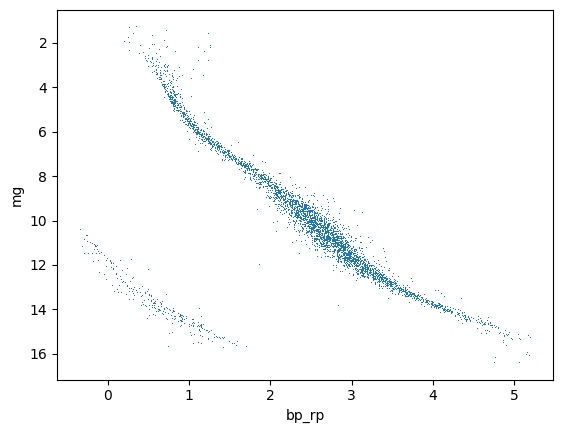

In [5]:
plt.plot(bp_rp, mg, lw=0, marker=',')
plt.gca().invert_yaxis()
plt.xlabel('bp_rp')
plt.ylabel('mg');

In [6]:
x1, y1 = 0, 8
x2, y2 = 3, 16.5
m_ms = (y2 - y1)/(x2 - x1)
b_ms = y1 - m_ms * x1

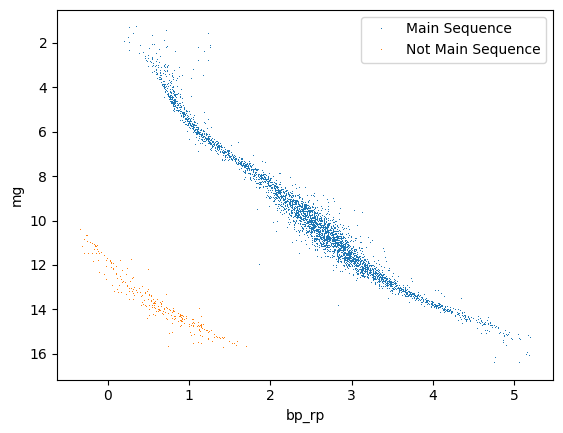

In [7]:
ms_sel = mg < m_ms * bp_rp + b_ms

plt.plot(bp_rp[ms_sel], mg[ms_sel], label='Main Sequence', lw=0, marker=',')
plt.plot(bp_rp[~ms_sel], mg[~ms_sel], label='Not Main Sequence', lw=0, marker=',')
plt.gca().invert_yaxis()
plt.xlabel('bp_rp')
plt.ylabel('mg')
plt.legend();

In [8]:
bp_rp = bp_rp[ms_sel]
mg = mg[ms_sel]

In [9]:
# write a function to build the hypothesis function based on given weight
#   expected arguments: theta_0, theta_1
#.     return a function
def build_hypothesis(theta_0, theta_1):
    def h(x):
        return theta_0 + theta_1 * x
    return h

# implement MSE cost function
#     expected arguments: theta_0, theta_1, x=bp_rp, y=mg
#.       return cost (scaler)
def cost(theta_0, theta_1, x=bp_rp, y=mg):
    m = len(x)
    h = build_hypothesis(theta_0, theta_1)

    return 1/(2*m) * np.sum(np.square(h(x) - y))

In [ ]:
(h(x) - y)**2

In [10]:
theta_0, theta_1 = 0, 0
print(cost(theta_0, theta_1))

52.67800502763864


$$
\mathrm{repeat~until~convergence} \{\\
\theta_j = \theta_j - \alpha \frac{\partial}{\partial\theta_j}J(\theta_0, \theta_1) \mathrm{~~~~for~}j=0\mathrm{~and~}j=1
\\\}
$$

We'll need the partial derivatives:
$$
\frac{\partial}{\partial\theta_0}J(\theta_0, \theta_1) = \frac{1}{m}\sum_{i=1}^m(\theta_0 + \theta_1 x^{(i)} - y^{(i)}) \\
\frac{\partial}{\partial\theta_1}J(\theta_0, \theta_1) = \frac{1}{m}\sum_{i=1}^m(\theta_0 + \theta_1 x^{(i)} - y^{(i)}) x^{(i)}
$$

In [11]:
m = len(bp_rp)
alpha = 0.01
nsteps = 5_000

thetas = np.zeros((nsteps, 2))
costs = np.zeros(nsteps)

for i in range(nsteps):
    h = build_hypothesis(theta_0, theta_1)

    theta_0 -= alpha/m * np.sum(h(bp_rp) - mg)
    theta_1 -= alpha/m * np.sum((h(bp_rp) - mg) * bp_rp)

    thetas[i] = theta_0, theta_1
    costs[i] = cost(theta_0, theta_1)

Text(0, 0.5, 'cost')

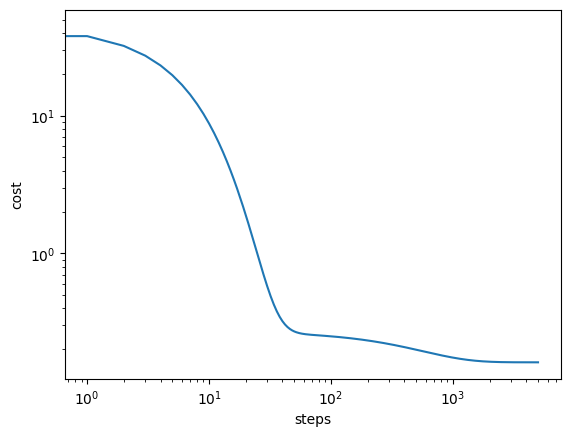

In [14]:
plt.loglog(costs)
plt.xlabel('steps')
plt.ylabel('cost')

In [15]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 4))

ax1.set_xlabel(r'$\theta_0$')
ax1.set_ylabel(r'$\theta_1$')
ax2.set_xlabel('iterations')
ax2.set_ylabel('cost')
ax2.set_yscale('log')

ax1.set_xlim(-.2, 3)
ax1.set_ylim(-.2, 3.5)
ax2.set_xlim(0, nsteps)
ax2.set_ylim(.1, 100)

scat = ax1.scatter(thetas[:1, 0], thetas[:1, 1], marker='.')
traj, = ax1.plot(thetas[:1, 0], thetas[:1, 1])
cost_trend, = ax2.plot(costs[:1])

def update(step):
    scat.set_offsets(thetas[:step])
    traj.set_xdata(thetas[:step, 0])
    traj.set_ydata(thetas[:step, 1])
    cost_trend.set_xdata(np.arange(step))
    cost_trend.set_ydata(costs[:step])
    return (scat, traj)

plt.close()
ani = animation.FuncAnimation(fig=fig, func=update, frames=range(0, nsteps, nsteps//200), interval=30)
HTML(ani.to_jshtml())

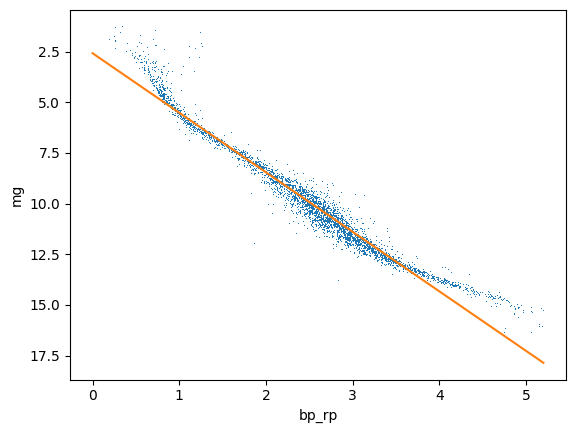

In [16]:
plt.plot(bp_rp, mg, lw=0, marker=',')
plt.gca().invert_yaxis()
plt.xlabel('bp_rp')
plt.ylabel('mg')

bp_rp_grid = np.linspace(0, 5.2, 2)
plt.plot(bp_rp_grid, build_hypothesis(theta_0, theta_1)(bp_rp_grid));